

# Maximum Covering
### OPIM 5641 — Business Decision Modeling · Module5

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/Module5/Maximum Covering.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Integer Programming: Maximum Covering (extracted from the textbook)

Related Readings:
* `Powell`: Chapter 11 (Integer Optimization)
* https://en.wikipedia.org/wiki/Set_cover_problem


# Problem description

* Consider now that **each location has a weight** proportional to its importance (e.g., number of houses in the location); you can also interpret this weight as demand

* Goal: place **up to $2$ stations** so as to maximize the covered demand

* Limit on the number of facilities is a cardinality constraint.

* The demand in each location is as follows:

location | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 15 | 16
--- | --- | --- | -- | -- | -- | -- | -- | -- | -- | -- | --| -- | -- | -- | -- | --
demand | 10 | 13 | 12 | 20 | 31 | 45 | 60 | 12 | 56 | 8 | 51 | 23 | 17 | 10 | 35 | 22

Remember the layout of the locations:

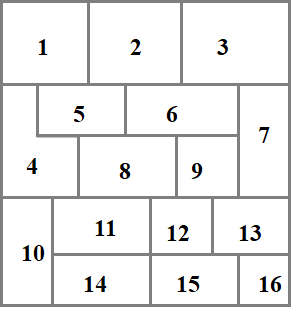


## Activation vs coverage

* Be careful with two different concepts going on in this problem: activation vs coverage
  * Activation: installing a fire station in a district
  * Coverage: having a fire station nearby
  * One distric may be covered by more than one fire station, but the demand should be counted only once!

## Setup Your Environment/Imports

In [ ]:
# before you do anything...
# mount your drive!
# click folder on the left...
# import modules

%matplotlib inline
from pylab import *

import shutil
import sys
import os.path

if not shutil.which("pyomo"):
    !pip install -q pyomo
    assert(shutil.which("pyomo"))

if not (shutil.which("cbc") or os.path.isfile("cbc")):
    if "google.colab" in sys.modules:
        !apt-get install -y -qq coinor-cbc
    else:
        try:
            !conda install -c conda-forge coincbc
        except:
            pass

assert(shutil.which("cbc") or os.path.isfile("cbc"))

from pyomo.environ import *

     |████████████████████████████████| 9.1 MB 5.2 MB/s 
     |████████████████████████████████| 49 kB 4.3 MB/s 
Selecting previously unselected package coinor-libcoinutils3v5.
(Reading database ... 155062 files and directories currently installed.)
Preparing to unpack .../0-coinor-libcoinutils3v5_2.10.14+repack1-1_amd64.deb ...
Unpacking coinor-libcoinutils3v5 (2.10.14+repack1-1) ...
Selecting previously unselected package coinor-libosi1v5.
Preparing to unpack .../1-coinor-libosi1v5_0.107.9+repack1-1_amd64.deb ...
Unpacking coinor-libosi1v5 (0.107.9+repack1-1) ...
Selecting previously unselected package coinor-libclp1.
Preparing to unpack .../2-coinor-libclp1_1.16.11+repack1-1_amd64.deb ...
Unpacking coinor-libclp1 (1.16.11+repack1-1) ...
Selecting previously unselected package coinor-libcgl1.
Preparing to unpack .../3-coinor-libcgl1_0.59.10+repack1-1_amd64.deb ...
Unpacking coinor-libcgl1 (0.59.10+repack1-1) ...
Selecting previously unselected package coinor-libcbc3.
Preparing to unp

**Define the Objective Function**

$\max \sum\limits_{i = 1}^{16}d_i y_i$ `(objective function)`

**Write the Constraints**


subject to:
* $x_1 + x_2 + x_4 + x_5 \geq y_1$       `(Site 1)`
* $x_1 + x_2 + x_3 + x_5 + x_6 \geq y_2$ `(Site 2)`
* $x_2 + x_3 + x_6 + x_7 \geq y_3$  `(Site 3)`
* $x_1 + x_4 + x_5 + x_8 + x_{10} + x_{11} \geq y_4$ `(Site 4)`
* $x_1 + x_2 + x_4 + x_5 + x_6 + x_8 \geq y_5$ `(Site 5)`
* $x_2 + x_3 + x_5 + x_6 + x_8 + x_7 + x_9 \geq y_6$ `(Site 6)`
* $x_3 + x_6 + x_7 + x_9 + x_{13} \geq y_7$ `(Site 7)`
* $x_4 + x_5 + x_6 + x_8 + x_9 + x_{11} + x_{12} \geq y_8$ `(Site 8)`
* $x_6 + x_7 + x_8 + x_9 + x_{12} + x_{13} \geq y_9$ `(Site 9)`
* $x_4 + x_{10} + x_{11} + x_{14} \geq y_{10}$ `(Site 10)`
* $x_4 + x_8 + x_{10} + x_{11} + x_{12} + x_{14} \geq y_{11}$ `(Site 11)`
* $x_8 + x_9 + x_{11} + x_{12} + x_{13} + x_{15} \geq y_{12}$ `(Site 12)`
* $x_7 + x_9 + x_{12} + x_{13} + x_{15} + x_{16} \geq y_{13}$ `(Site 13)`
* $x_{10} + x_{11} + x_{14} + x_{15} \geq y_{14}$ `(Site 14)`
* $x_{12} + x_{13} + x_{14} + x_{15} + x_{16} \geq y_{15}$ `(Site 15)`
* $x_{13} + x_{15} + x_{16} \geq y_{16}$ `(Site 16)`

`Domains`
* $x_i \in \{0,1\}, i \in [16]$  `(only binary activation variables)`

`At most 2 fire stations`
* $\sum\limits_{i = 1}^{16}x_i \leq 2$

`Domains`
* $ x_i \in \{0,1\}, i \in [16]$ `activation variables`
* $ y_i \in \{0,1\}, i \in [16]$ `coverage variables`

Note the interplay of $x$ and $y$... the objective function is composed of $y$ (coverage variables) while the constraints are made as a function of $x$ (activation variables) and $y$ (coverage variables.)

For example, Station 1 is covered ($y_1 = 1$) if we activate either $x_1$, $x_2$, $x_4$ or $x_5$. Note the consistency relationship - I cannot cover $y_1$ if I don't activate $x_1$, $x_2$, $x_4$ or $x_5$. Put another way, I can have $x_1 + x_2 + x_4 + x_5 = 0$ and $y_1=0$ at the same time, but I can't have $y_1 = 1$ if the $x_1 + x_2 + x_4 + x_5 = 0$ and $y_1=0$

In [ ]:
# declare the model
model = ConcreteModel()

stations = range(1,17)
demand = [0, 10, 13, 12, 20, 31, 45, 60, 12, 56, 8, 51, 23, 17, 10, 35, 22]
neighbours = [
              [], # Empty list because lists start from zero
              [1,2,4,5],
              [1,2,3,5,6],
              [2,3,6,7],
              [1,4,5,8,10,11],
              [1,2,4,5,6,8], # Site 5
              [2,3,5,6,7,8,9],
              [3,6,7,9,13],
              [4,5,6,8,9,11,12],
              [6,7,8,9,12,13],
              [4,10,11,14], # Site 10
              [4,8,10,11,12,14],
              [8,9,11,12,13,15],
              [7,9,12,13,15,16],
              [10,11,14,15],
              [12,13,14,15,16], # Site 15
              [13,15,16]
]

# declare decision variables
model.selected = Var(stations, domain=Binary)
model.covered = Var(stations, domain=Binary)

obj_expr = 0
for station in stations:
  obj_expr += demand[station]*model.covered[station]


# declare objective
model.coverage = Objective(
                      expr = obj_expr, # values come from the table
                      sense = maximize)

# declare constraints
model.constraints = ConstraintList()

# Activation variables for station coverage
for station in stations:
  neigh_expr = 0
  for neighbour in neighbours[station]:
    neigh_expr += model.selected[neighbour]
  model.constraints.add(neigh_expr >= model.covered[station])

# Bound on maximum number of selected locations
selected_expr = 0
for station in stations:
  selected_expr += model.selected[station]
model.constraints.add(selected_expr <= 2)

# show the model you've created
model.pprint()

3 Set Declarations
    constraints_index : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   17 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17}
    covered_index : Size=1, Index=None, Ordered=False
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   16 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16}
    selected_index : Size=1, Index=None, Ordered=False
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   16 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16}

2 Var Declarations
    covered : Size=16, Index=covered_index
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :     0 :  None :     1 : False :  True : Binary
          2 :     0 :  None :     1 : False :  True : Binary
          3 :     0 :  None :     1 : False :  True : Binary
          4 :     0 :  None :     1 : False :  True : Binary
          5 

In [ ]:
# solve it
SolverFactory('cbc', executable='/usr/bin/cbc').solve(model).write()
# show the results
print("Number of stations = ", model.coverage())
for station in stations:
  print("Station",station,":",model.selected[station]())

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 372.0
  Upper bound: 372.0
  Number of objectives: 1
  Number of constraints: 17
  Number of variables: 32
  Number of binary variables: 32
  Number of integer variables: 32
  Number of nonzeros: 16
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.0
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: